# Solar Irradiance Prediction (without Kathmandu)

This notebook predicts Solar Irradiance using XGBoost, Random Forest, KNN, LSTM, and ANN-MLP for Kathmandu.
Dataset1 (2014-2022) is used for training and test splitting (80/20).
Dataset2 (Jan-Sep 2023) is used for model evaluation.


In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import os
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ModelCheckpoint
import tensorflow as tf

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configuration
# Options: 'nuwakot_data.csv', 'dhangadhi_data.csv', 'mustang_data.csv', 'taplejung_data.csv'
DATA_FILE = "ktm_data.csv"
REGION_NAME = DATA_FILE.split('_')[0].capitalize()

BASE_PATH = "/content/drive/MyDrive/Solar/Data_solar"
DATA_PATH = os.path.join(BASE_PATH, DATA_FILE)
MODEL_SAVE_DIR = "/content/drive/MyDrive/RESEARCH/Solar/Model_Works/model"

print(f"Selected Region: {REGION_NAME}")


Selected Region: Dhangadhi


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Create model directory if it doesn't exist
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)


In [ ]:
# Load and inspect data
data = pd.read_csv(DATA_PATH)
print(f"Data shape: {data.shape}")
print(f"Columns: {list(data.columns)}")
print(f"Date range: {data['YEAR'].min()}-{data['YEAR'].max()}")
data.head()


Data shape: (87648, 23)
Columns: ['YEAR', 'MO', 'DY', 'HR', 'ALLSKY_SFC_SW_DWN', 'CLRSKY_SFC_SW_DWN', 'ALLSKY_KT', 'ALLSKY_SRF_ALB', 'SZA', 'ALLSKY_SFC_PAR_TOT', 'CLRSKY_SFC_PAR_TOT', 'ALLSKY_SFC_UVA', 'ALLSKY_SFC_UVB', 'ALLSKY_SFC_UV_INDEX', 'T2M', 'T2MDEW', 'T2MWET', 'QV2M', 'RH2M', 'PRECTOTCORR', 'PS', 'WS10M', 'WD10M']
Date range: 2014-2024


,YEAR,MO,DY,HR,ALLSKY_SFC_SW_DWN,CLRSKY_SFC_SW_DWN,ALLSKY_KT,ALLSKY_SRF_ALB,SZA,ALLSKY_SFC_PAR_TOT,...,ALLSKY_SFC_UV_INDEX,T2M,T2MDEW,T2MWET,QV2M,RH2M,PRECTOTCORR,PS,WS10M,WD10M
0,2014,1,1,5,0.00,0.00,-999.00,-999.00,-999.00,0.00,...,0.00,11.21,8.03,9.62,6.84,81.06,0.03,99.11,2.14,325.09
1,2014,1,1,6,9.02,6.55,0.35,0.09,88.96,2.55,...,0.00,11.28,7.72,9.50,6.65,79.06,0.03,99.16,2.08,319.12
2,2014,1,1,7,115.50,120.42,0.45,0.12,79.54,47.38,...,0.10,13.08,9.40,11.24,7.45,78.69,0.01,99.23,1.89,309.96
3,2014,1,1,8,283.89,297.80,0.57,0.06,69.22,120.55,...,0.67,15.01,10.00,12.50,7.75,72.06,0.00,99.32,2.60,297.18
4,2014,1,1,9,456.27,455.58,0.66,0.09,60.59,195.02,...,1.67,17.35,10.48,13.92,8.00,64.00,0.00,99.38,3.02,283.17


In [ ]:
print(f"Checking contents of: {BASE_PATH}")
if os.path.exists(BASE_PATH):
    print(os.listdir(BASE_PATH))
else:
    print(f"The base path does not exist: {BASE_PATH}")

Checking contents of: /content/drive/MyDrive/Solar/Data_solar
['dhangadhi_data.csv', 'ktm_data.csv', 'mustang_data.csv', 'nuwakot_data.csv', 'taplejung_data.csv']


In [ ]:
# Data preprocessing
# Convert date columns to numeric
date_cols = ['YEAR', 'MO', 'DY', 'HR']
for col in date_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Drop rows with any NaN values
data = data.dropna()

# Drop problematic columns with many missing values (-999) and target-derived variables
cols_to_drop = [
    'ALLSKY_SRF_ALB', 'SZA', 'ALLSKY_KT',
    'CLRSKY_SFC_SW_DWN', 'ALLSKY_SFC_PAR_TOT', 'CLRSKY_SFC_PAR_TOT',
    'ALLSKY_SFC_UVA', 'ALLSKY_SFC_UVB', 'ALLSKY_SFC_UV_INDEX'
]
data = data.drop(cols_to_drop, axis=1, errors='ignore')

# Rename columns for clarity
rename_dict = {
    'YEAR': 'Year', 'MO': 'Month', 'DY': 'Day', 'HR': 'Hour',
    'ALLSKY_SFC_SW_DWN': 'Solar_Irradiance',
    'T2MDEW': 'DEW2M',
    'QV2M': 'SH2M',
    'PRECTOTCORR': 'Precipitation',
    'PS': 'SP'
}
data.rename(columns=rename_dict, inplace=True)

# Replace remaining -999 values with 0
data = data.replace(-999, 0)

print(f"Data shape after cleaning: {data.shape}")
data.head()


Data shape after cleaning: (87648, 14)


,Year,Month,Day,Hour,Solar_Irradiance,T2M,DEW2M,T2MWET,SH2M,RH2M,Precipitation,SP,WS10M,WD10M
0,2014,1,1,5,0.00,11.21,8.03,9.62,6.84,81.06,0.03,99.11,2.14,325.09
1,2014,1,1,6,9.02,11.28,7.72,9.50,6.65,79.06,0.03,99.16,2.08,319.12
2,2014,1,1,7,115.50,13.08,9.40,11.24,7.45,78.69,0.01,99.23,1.89,309.96
3,2014,1,1,8,283.89,15.01,10.00,12.50,7.75,72.06,0.00,99.32,2.60,297.18
4,2014,1,1,9,456.27,17.35,10.48,13.92,8.00,64.00,0.00,99.38,3.02,283.17


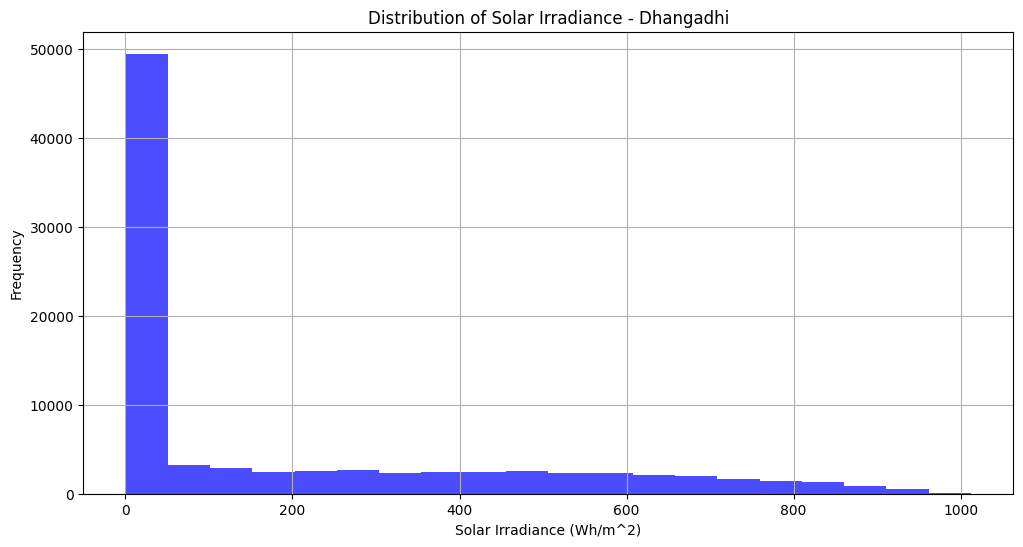

In [ ]:
# Exploratory Data Analysis (EDA)
plt.figure(figsize=(12, 6))
plt.hist(data['Solar_Irradiance'], bins=20, alpha=0.7, color='blue')
plt.xlabel('Solar Irradiance (Wh/m^2)')
plt.ylabel('Frequency')
plt.title(f'Distribution of Solar Irradiance - {REGION_NAME}')
plt.grid(True)
plt.show()


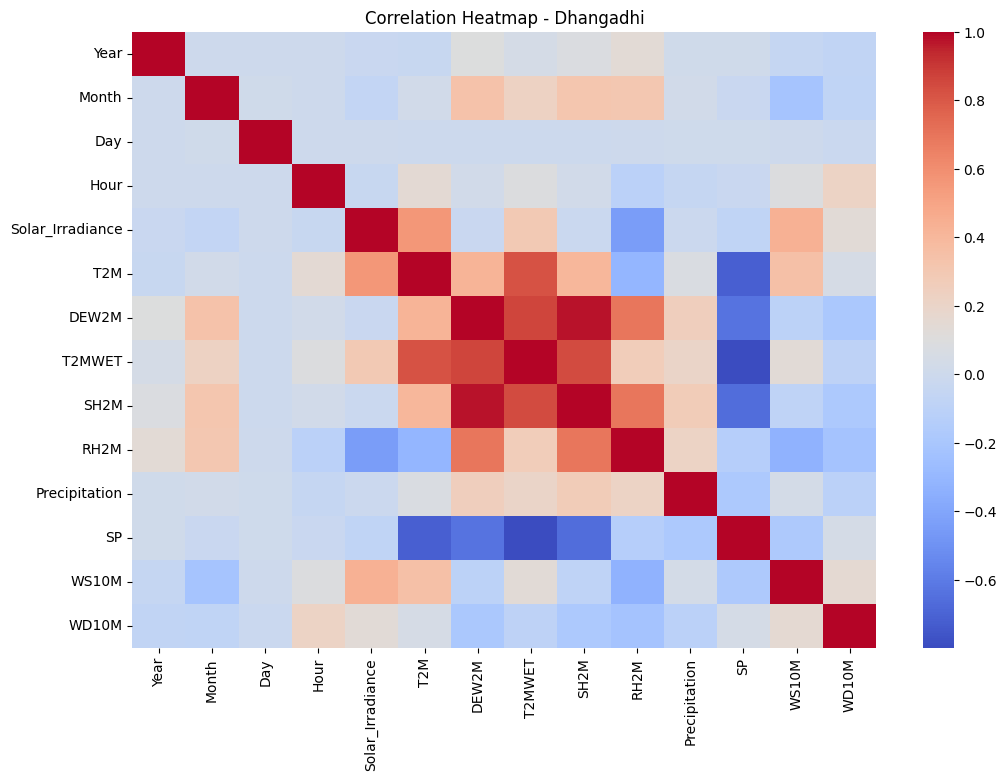

In [ ]:
# Correlation Heatmap
correlation_matrix = data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title(f'Correlation Heatmap - {REGION_NAME}')
plt.show()


In [ ]:
# Split into Dataset1 (2014-2022) and Dataset2 (Jan-Sep 2023)
data1 = data[data['Year'] <= 2022].copy()
data2 = data[(data['Year'] == 2023) & (data['Month'] <= 9)].copy()

print(f"Dataset1 (2014-2022) shape: {data1.shape}")
print(f"Dataset2 (2023) shape: {data2.shape}")


Dataset1 (2014-2022) shape: (78883, 14)
Dataset2 (2023) shape: (6552, 14)


In [ ]:
# Feature/Target Split for Dataset1
target_col = 'Solar_Irradiance'
X = data1.drop([target_col], axis=1)
y = data1[target_col]

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")


Train size: 63106, Test size: 15777


In [ ]:
# Function to evaluate and print metrics
def evaluate_model(actual, predicted, model_name, dataset_name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mbe = np.mean(actual - predicted)
    r2 = r2_score(actual, predicted)

    print(f"--- {model_name} on {dataset_name} ---")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Bias Error (MBE): {mbe:.4f}")
    print(f"R-squared (R²): {r2:.4f}\n")
    return mae, rmse, mbe, r2

metrics_dict = {}


In [ ]:
# Prepare Dataset2 features and target
X_dataset2 = data2.drop([target_col], axis=1)
y_dataset2 = data2[target_col]


## 1. XGBoost Regressor


In [ ]:
xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)

# Evaluate on Dataset1 Test set
xgb_pred_test = xgb_model.predict(X_test)
evaluate_model(y_test, xgb_pred_test, "XGBoost", "Dataset1 Test Set")

# Evaluate on Dataset2 (2023)
xgb_pred_dataset2 = xgb_model.predict(X_dataset2)
xgb_metrics = evaluate_model(y_dataset2, xgb_pred_dataset2, "XGBoost", "Dataset2 (2023)")
metrics_dict['XGBoost'] = xgb_metrics

# Save model
joblib.dump(xgb_model, os.path.join(MODEL_SAVE_DIR, f'xgboost_{REGION_NAME.lower()}.pkl'))


--- XGBoost on Dataset1 Test Set ---
Mean Absolute Error (MAE): 28.8981
Root Mean Squared Error (RMSE): 55.4946
Mean Bias Error (MBE): 0.3230
R-squared (R²): 0.9569

--- XGBoost on Dataset2 (2023) ---
Mean Absolute Error (MAE): 44.2042
Root Mean Squared Error (RMSE): 82.2408
Mean Bias Error (MBE): 6.5199
R-squared (R²): 0.9110



['/content/drive/MyDrive/RESEARCH/Solar/Model_Works/model/xgboost_dhangadhi.pkl']

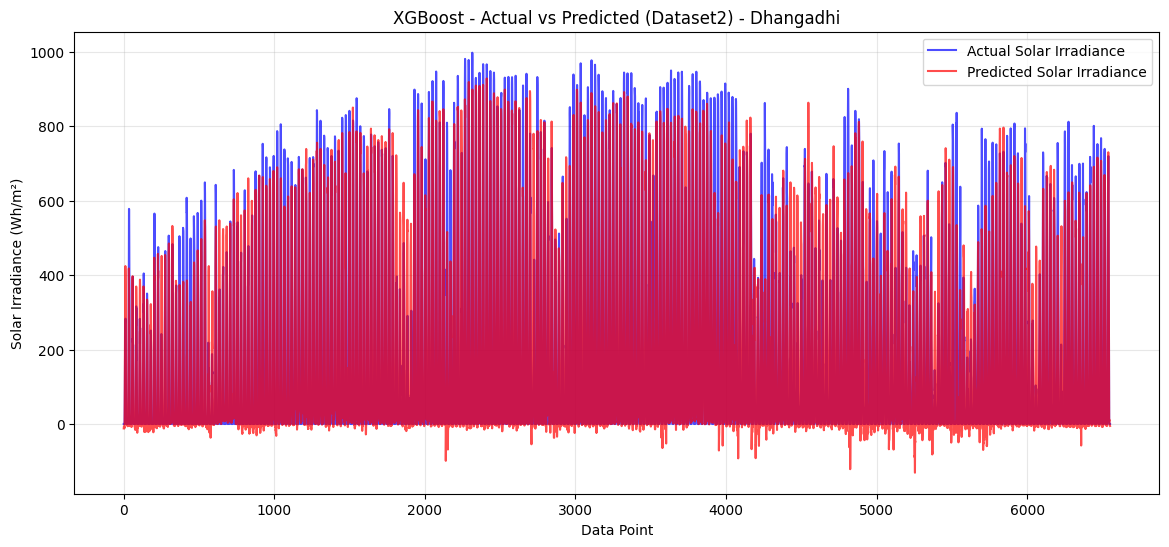

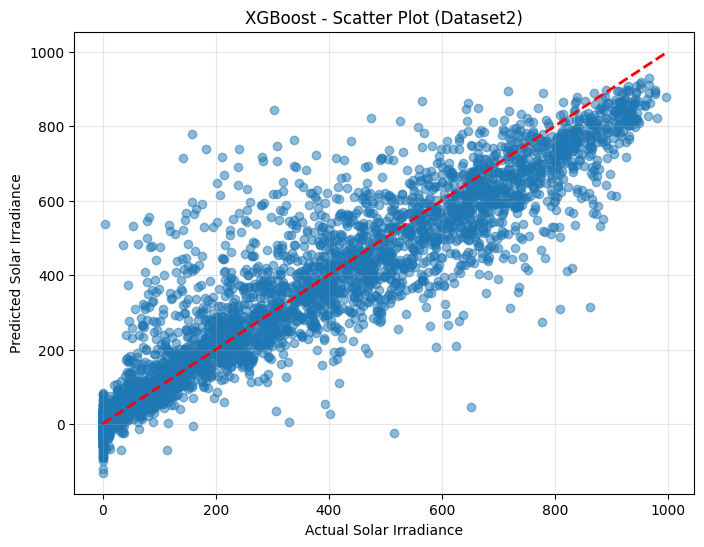

In [ ]:
# XGBoost Plots for Dataset2
plt.figure(figsize=(14, 6))
plt.plot(y_dataset2.values, label='Actual Solar Irradiance', color='blue', alpha=0.7)
plt.plot(xgb_pred_dataset2, label='Predicted Solar Irradiance', color='red', alpha=0.7)
plt.title(f'XGBoost - Actual vs Predicted (Dataset2) - {REGION_NAME}')
plt.xlabel('Data Point')
plt.ylabel('Solar Irradiance (Wh/m²)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(y_dataset2, xgb_pred_dataset2, alpha=0.5)
plt.plot([y_dataset2.min(), y_dataset2.max()], [y_dataset2.min(), y_dataset2.max()], 'r--', lw=2)
plt.xlabel('Actual Solar Irradiance')
plt.ylabel('Predicted Solar Irradiance')
plt.title('XGBoost - Scatter Plot (Dataset2)')
plt.grid(True, alpha=0.3)
plt.show()


## 2. Random Forest Regressor


In [ ]:
rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Evaluate on Dataset1 Test set
rf_pred_test = rf_model.predict(X_test)
evaluate_model(y_test, rf_pred_test, "Random Forest", "Dataset1 Test Set")

# Evaluate on Dataset2 (2023)
rf_pred_dataset2 = rf_model.predict(X_dataset2)
rf_metrics = evaluate_model(y_dataset2, rf_pred_dataset2, "Random Forest", "Dataset2 (2023)")
metrics_dict['Random Forest'] = rf_metrics

# Save model
joblib.dump(rf_model, os.path.join(MODEL_SAVE_DIR, f'randomforest_{REGION_NAME.lower()}.pkl'))


--- Random Forest on Dataset1 Test Set ---
Mean Absolute Error (MAE): 25.5261
Root Mean Squared Error (RMSE): 55.3160
Mean Bias Error (MBE): 0.5482
R-squared (R²): 0.9572

--- Random Forest on Dataset2 (2023) ---
Mean Absolute Error (MAE): 36.1798
Root Mean Squared Error (RMSE): 74.9748
Mean Bias Error (MBE): 2.1656
R-squared (R²): 0.9261



['/content/drive/MyDrive/RESEARCH/Solar/Model_Works/model/randomforest_dhangadhi.pkl']

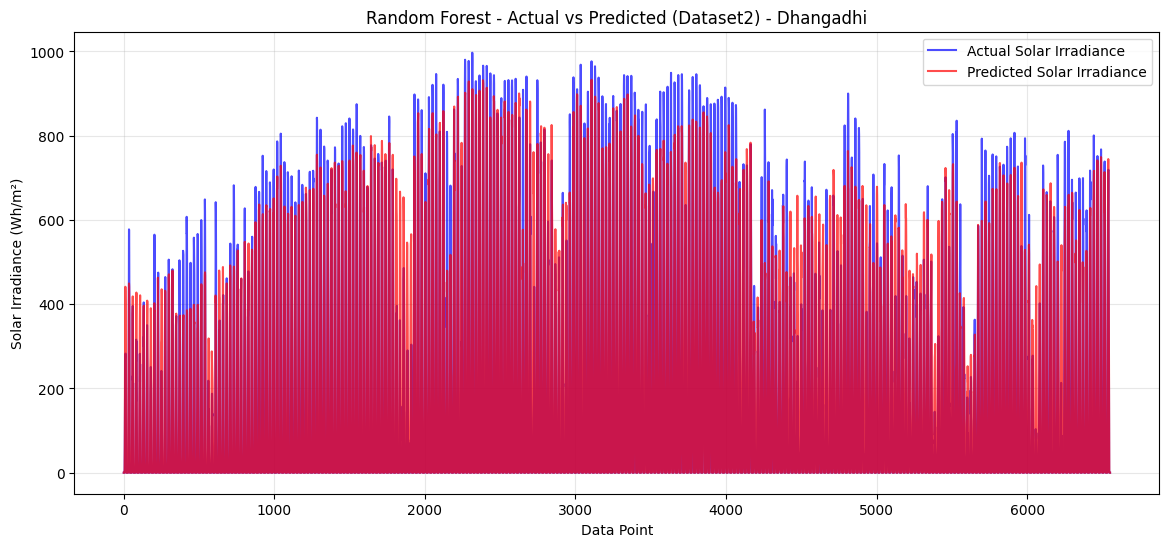

In [ ]:
# Random Forest Plots for Dataset2
plt.figure(figsize=(14, 6))
plt.plot(y_dataset2.values, label='Actual Solar Irradiance', color='blue', alpha=0.7)
plt.plot(rf_pred_dataset2, label='Predicted Solar Irradiance', color='red', alpha=0.7)
plt.title(f'Random Forest - Actual vs Predicted (Dataset2) - {REGION_NAME}')
plt.xlabel('Data Point')
plt.ylabel('Solar Irradiance (Wh/m²)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 3. K-Nearest Neighbors Regressor


In [ ]:
knn_model = KNeighborsRegressor()
knn_model.fit(X_train, y_train)

# Evaluate on Dataset1 Test set
knn_pred_test = knn_model.predict(X_test)
evaluate_model(y_test, knn_pred_test, "KNN", "Dataset1 Test Set")

# Evaluate on Dataset2 (2023)
knn_pred_dataset2 = knn_model.predict(X_dataset2)
knn_metrics = evaluate_model(y_dataset2, knn_pred_dataset2, "KNN", "Dataset2 (2023)")
metrics_dict['KNN'] = knn_metrics

# Save model
joblib.dump(knn_model, os.path.join(MODEL_SAVE_DIR, f'knn_{REGION_NAME.lower()}.pkl'))


--- KNN on Dataset1 Test Set ---
Mean Absolute Error (MAE): 61.3093
Root Mean Squared Error (RMSE): 104.7319
Mean Bias Error (MBE): -4.9437
R-squared (R²): 0.8466

--- KNN on Dataset2 (2023) ---
Mean Absolute Error (MAE): 82.9948
Root Mean Squared Error (RMSE): 135.1874
Mean Bias Error (MBE): -6.2548
R-squared (R²): 0.7596



['/content/drive/MyDrive/RESEARCH/Solar/Model_Works/model/knn_dhangadhi.pkl']

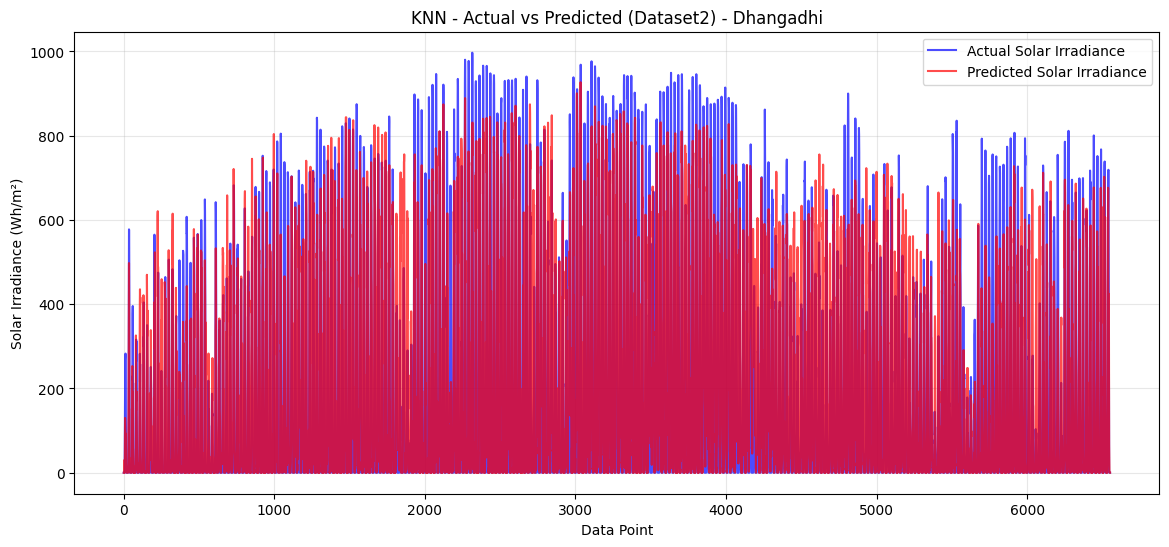

In [ ]:
# KNN Plots for Dataset2
plt.figure(figsize=(14, 6))
plt.plot(y_dataset2.values, label='Actual Solar Irradiance', color='blue', alpha=0.7)
plt.plot(knn_pred_dataset2, label='Predicted Solar Irradiance', color='red', alpha=0.7)
plt.title(f'KNN - Actual vs Predicted (Dataset2) - {REGION_NAME}')
plt.xlabel('Data Point')
plt.ylabel('Solar Irradiance (Wh/m²)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 4. LSTM Neural Network


In [ ]:
# Standardize the data for deep learning models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_dataset2_scaled = scaler.transform(X_dataset2)

# Save scaler
joblib.dump(scaler, os.path.join(MODEL_SAVE_DIR, f'scaler_{REGION_NAME.lower()}.pkl'))

# Reshape for LSTM [samples, time steps, features]
X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
X_test_lstm = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])
X_dataset2_lstm = X_dataset2_scaled.reshape(X_dataset2_scaled.shape[0], 1, X_dataset2_scaled.shape[1])


In [ ]:
# Build LSTM Model
lstm_model = Sequential([
    LSTM(64, activation='relu', return_sequences=True, input_shape=(1, X_train_scaled.shape[1])),
    Dropout(0.2),
    LSTM(32, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['mae'])

early_stopping = EarlyStopping(
    monitor='val_loss',
    min_delta=0.001,
    patience=10,
    restore_best_weights=True
)

lstm_history = lstm_model.fit(
    X_train_lstm, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_test_lstm, y_test),
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1973/1973 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 30388.4746 - mae: 109.3800 - val_loss: 12835.5322 - val_mae: 70.8447
Epoch 2/100
1973/1973 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 11451.5928 - mae: 63.6038 - val_loss: 8389.1230 - val_mae: 52.9770
Epoch 3/100
1973/1973 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 8306.6113 - mae: 52.1662 - val_loss: 6239.6660 - val_mae: 44.4936
Epoch 4/100
1973/1973 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 6682.8804 - mae: 45.8454 - val_loss: 5345.7871 - val_mae: 40.2478
Epoch 5/100
1973/1973 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 5978.6704 - mae: 42.6361 - val_loss: 4994.7153 - val_mae: 38.2697
Epoch 6/100
1973/1973 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 5611.9648 - mae: 40.5281 - val_loss: 4783.0166 - val_mae: 36.6340
Epoch 7/100
1973/1973 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 5420.8320 - mae: 39.4757 - val_loss: 4661.2666 - val_mae: 36.2083
Epoch 8/100
1973/1973 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 5232.5107 - mae: 38.2783 - val_loss:

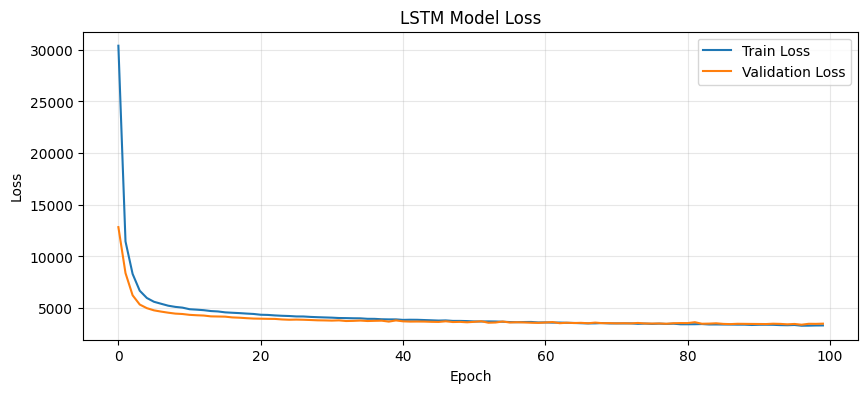

In [ ]:
# Plot LSTM Training History
plt.figure(figsize=(10, 4))
plt.plot(lstm_history.history['loss'], label='Train Loss')
plt.plot(lstm_history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
# Evaluate on Dataset1 Test set
lstm_pred_test = lstm_model.predict(X_test_lstm, verbose=0).flatten()
evaluate_model(y_test, lstm_pred_test, "LSTM", "Dataset1 Test Set")

# Evaluate on Dataset2 (2023)
lstm_pred_dataset2 = lstm_model.predict(X_dataset2_lstm, verbose=0).flatten()
lstm_metrics = evaluate_model(y_dataset2, lstm_pred_dataset2, "LSTM", "Dataset2 (2023)")
metrics_dict['LSTM'] = lstm_metrics

# Save model
lstm_model.save(os.path.join(MODEL_SAVE_DIR, f'lstm_{REGION_NAME.lower()}.h5'))


--- LSTM on Dataset1 Test Set ---
Mean Absolute Error (MAE): 29.5455
Root Mean Squared Error (RMSE): 58.2496
Mean Bias Error (MBE): 4.5667
R-squared (R²): 0.9525



--- LSTM on Dataset2 (2023) ---
Mean Absolute Error (MAE): 41.7816
Root Mean Squared Error (RMSE): 80.3833
Mean Bias Error (MBE): 7.4964
R-squared (R²): 0.9150



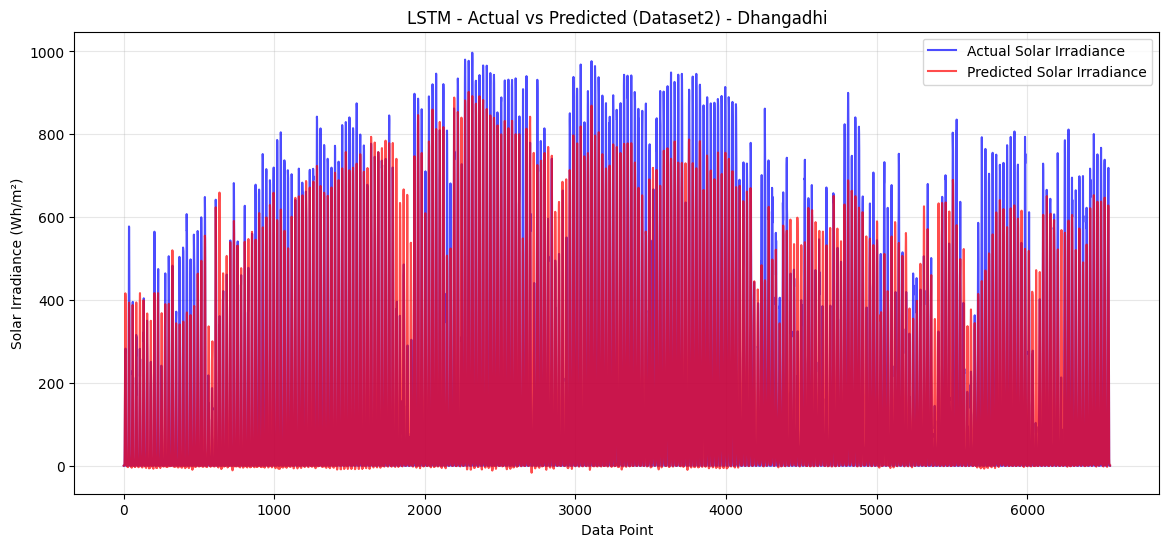

In [ ]:
# LSTM Plots for Dataset2
plt.figure(figsize=(14, 6))
plt.plot(y_dataset2.values, label='Actual Solar Irradiance', color='blue', alpha=0.7)
plt.plot(lstm_pred_dataset2, label='Predicted Solar Irradiance', color='red', alpha=0.7)
plt.title(f'LSTM - Actual vs Predicted (Dataset2) - {REGION_NAME}')
plt.xlabel('Data Point')
plt.ylabel('Solar Irradiance (Wh/m²)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 5. Artificial Neural Network (ANN-MLP)


In [ ]:
# Build ANN-MLP Model
ann_model = Sequential([
    Dense(16, activation='relu', input_dim=X_train_scaled.shape[1]),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

ann_model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

early_stopping_ann = EarlyStopping(
    monitor='val_loss',
    min_delta=0.00001,
    patience=15,
    restore_best_weights=True
)

ann_history = ann_model.fit(
    X_train_scaled, y_train,
    batch_size=32,
    epochs=200,
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stopping_ann],
    verbose=1
)


Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1973/1973 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 37730.3008 - mae: 133.5115 - val_loss: 19810.1445 - val_mae: 98.2362
Epoch 2/200
1973/1973 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 18624.5449 - mae: 93.6694 - val_loss: 17772.9766 - val_mae: 90.7490
Epoch 3/200
1973/1973 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 17360.0762 - mae: 89.7391 - val_loss: 16881.5078 - val_mae: 88.1161
Epoch 4/200
1973/1973 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 16639.0820 - mae: 87.4379 - val_loss: 16299.5693 - val_mae: 86.1539
Epoch 5/200
1973/1973 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 16149.3896 - mae: 85.6313 - val_loss: 15877.5205 - val_mae: 84.4736
Epoch 6/200
1973/1973 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 15725.0820 - mae: 83.9005 - val_loss: 15356.9980 - val_mae: 82.5317
Epoch 7/200
1973/1973 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 14956.6650 - mae: 81.6473 - val_loss: 14354.9072 - val_mae: 80.0727
Epoch 8/200
1973/1973 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 13715.1367 - mae: 78.5941 - val

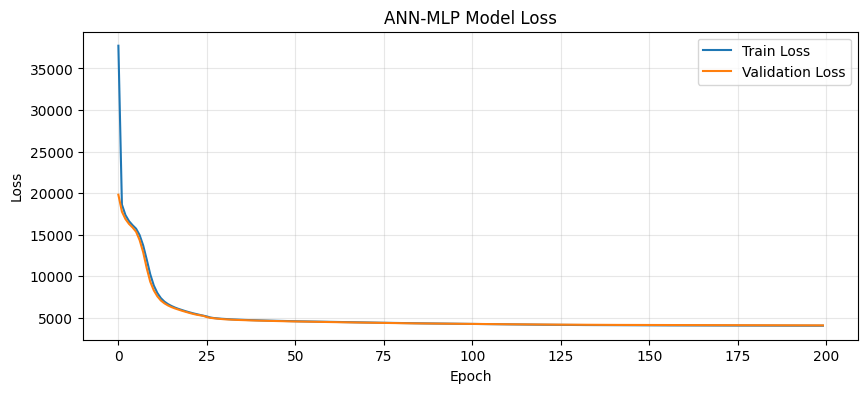

In [ ]:
# Plot ANN Training History
plt.figure(figsize=(10, 4))
plt.plot(ann_history.history['loss'], label='Train Loss')
plt.plot(ann_history.history['val_loss'], label='Validation Loss')
plt.title('ANN-MLP Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
# Evaluate on Dataset1 Test set
ann_pred_test = ann_model.predict(X_test_scaled, verbose=0).flatten()
evaluate_model(y_test, ann_pred_test, "ANN-MLP", "Dataset1 Test Set")

# Evaluate on Dataset2 (2023)
ann_pred_dataset2 = ann_model.predict(X_dataset2_scaled, verbose=0).flatten()
ann_metrics = evaluate_model(y_dataset2, ann_pred_dataset2, "ANN-MLP", "Dataset2 (2023)")
metrics_dict['ANN-MLP'] = ann_metrics

# Save model
ann_model.save(os.path.join(MODEL_SAVE_DIR, f'ann_{REGION_NAME.lower()}.h5'))


--- ANN-MLP on Dataset1 Test Set ---
Mean Absolute Error (MAE): 31.9237
Root Mean Squared Error (RMSE): 64.0166
Mean Bias Error (MBE): -1.1635
R-squared (R²): 0.9427



--- ANN-MLP on Dataset2 (2023) ---
Mean Absolute Error (MAE): 37.9815
Root Mean Squared Error (RMSE): 73.4206
Mean Bias Error (MBE): -5.8217
R-squared (R²): 0.9291



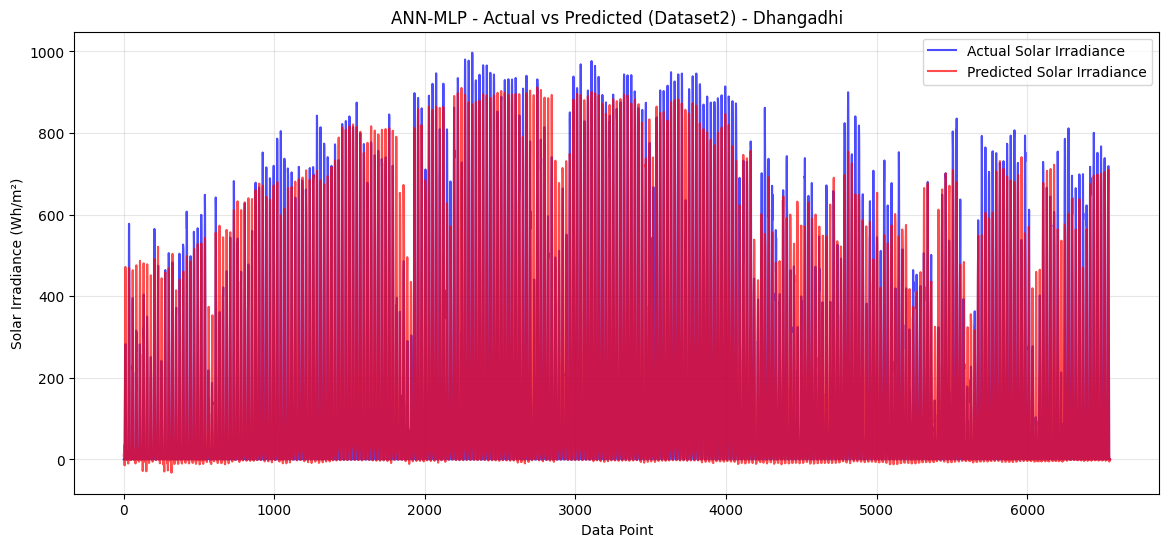

In [ ]:
# ANN Plots for Dataset2
plt.figure(figsize=(14, 6))
plt.plot(y_dataset2.values, label='Actual Solar Irradiance', color='blue', alpha=0.7)
plt.plot(ann_pred_dataset2, label='Predicted Solar Irradiance', color='red', alpha=0.7)
plt.title(f'ANN-MLP - Actual vs Predicted (Dataset2) - {REGION_NAME}')
plt.xlabel('Data Point')
plt.ylabel('Solar Irradiance (Wh/m²)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Summary of Model Performances on Dataset2 (2023)


In [ ]:
# Create a summary DataFrame
metrics_df = pd.DataFrame.from_dict(
    metrics_dict,
    orient='index',
    columns=['MAE', 'RMSE', 'MBE', 'R²']
)

print(f"--- Performance Comparison on Dataset2 ({REGION_NAME}) ---")
display(metrics_df.round(4))


--- Performance Comparison on Dataset2 (Dhangadhi) ---


,MAE,RMSE,MBE,R²
XGBoost,44.2042,82.2408,6.5199,0.9110
Random Forest,36.1798,74.9748,2.1656,0.9261
KNN,82.9948,135.1874,-6.2548,0.7596
LSTM,41.7816,80.3833,7.4964,0.9150
ANN-MLP,37.9815,73.4206,-5.8217,0.9291
